In [25]:
# @title get GEE authorization
import ee

# Trigger the authentication flow.
ee.Authenticate()
# Initialize the library.
ee.Initialize(project='projet-hrms')

In [26]:
import pandas as pd

# @title read csv file: points id with coordinates

df_sites = pd.read_csv('ISMN_PSA_merged_sites_with_features.csv')
df_sites = df_sites[['ID', 'Longitude', 'Latitude']]

# @title define feature collections
lons_sub = ee.List(df_sites['Longitude'].tolist())
lats_sub = ee.List(df_sites['Latitude'].tolist())
idnum_sub = ee.List(df_sites['ID'].tolist())
points = lons_sub.zip(lats_sub).zip(idnum_sub).map(lambda coords: ee.Feature(ee.Geometry.Point(ee.List(coords).get(0)),{'id_num': ee.List(coords).get(1)}))
feature_collection = ee.FeatureCollection(points)


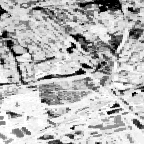
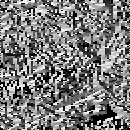
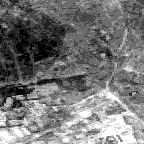
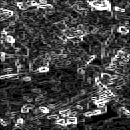
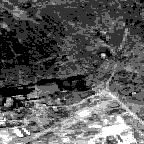
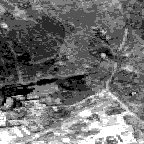
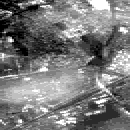
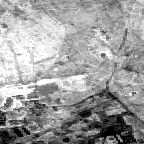
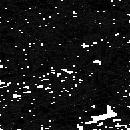
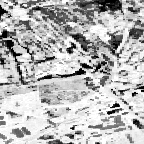
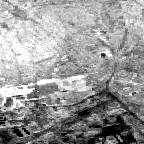
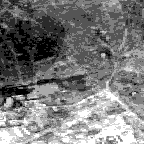
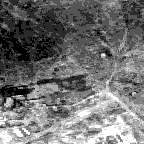
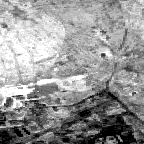
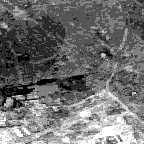
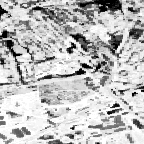

In [27]:
import folium
import rasterio
import numpy as np
import os

# Répertoire de base
base_dir = "./gee_export/sites"

# Initialisation de la carte
m = folium.Map(location=[46.603354, 1.888334], zoom_start=6)  # Centré sur la France par défaut

# Ajout d'une couche de base (Satellite)
folium.TileLayer(
    tiles='https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}',
    attr='Google Satellite',
    name='Satellite',
    overlay=True
).add_to(m)

# Parcourir les sites et les fichiers TIFF
site = "site_0"
site_path = os.path.join(base_dir, site)

for tif_file in os.listdir(site_path):
    if tif_file.endswith(".tif"):
        tif_path = os.path.join(site_path, tif_file)

        with rasterio.open(tif_path) as src:
            data = src.read(1)
            bounds = src.bounds

            # Normalisation des données
            data = np.nan_to_num(data)
             # Étirement linéaire (Min-Max)
             
            p_low, p_high = 2, 98  # Percentiles à utiliser
            data_min = np.percentile(data, p_low)
            data_max = np.percentile(data, p_high)
            stretched_data = (data - data_min) / (data_max - data_min)

            # Clipper les valeurs entre 0 et 1
            stretched_data = np.clip(stretched_data, 0, 1)

            # Ajout de la couche raster
            folium.raster_layers.ImageOverlay(
                image=stretched_data,
                bounds=[[bounds.bottom, bounds.left], [bounds.top, bounds.right]],
                opacity=0.7,
                name=f"Site {site} - {tif_file}",
                interactive=True
            ).add_to(m)


# Recentrage de la carte sur le site
m.fit_bounds([[bounds.bottom, bounds.left], [bounds.top, bounds.right]])

# Ajout du contrôle des couches
folium.LayerControl().add_to(m)

# Affichage de la carte
m

In [28]:
import pandas as pd

# @title read csv file: points id with coordinates

df_sites = pd.read_csv('ISMN_PSA_merged_sites_with_features.csv')
df_sites = df_sites[['ID', 'Longitude', 'Latitude']]

# @title define feature collections
lons_sub = ee.List(df_sites['Longitude'].tolist())
lats_sub = ee.List(df_sites['Latitude'].tolist())
idnum_sub = ee.List(df_sites['ID'].tolist())
points = lons_sub.zip(lats_sub).zip(idnum_sub).map(lambda coords: ee.Feature(ee.Geometry.Point(ee.List(coords).get(0)),{'id_num': ee.List(coords).get(1)}))
feature_collection = ee.FeatureCollection(points)


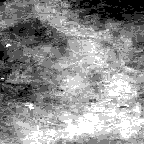
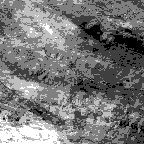
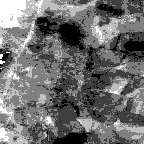
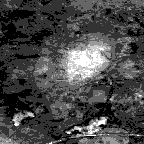
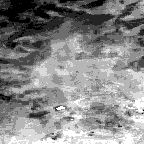
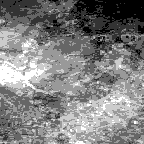
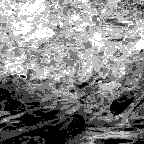
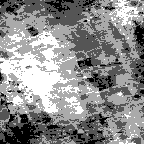
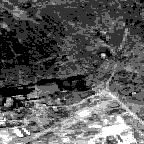
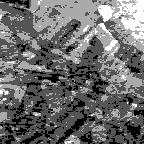
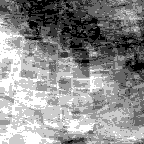
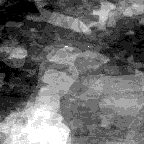
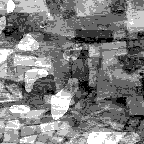
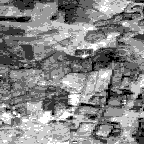
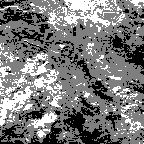
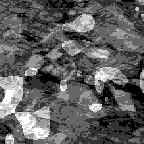
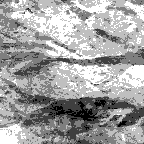
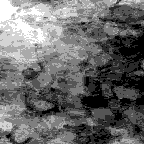
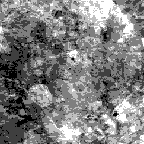
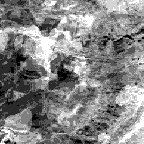
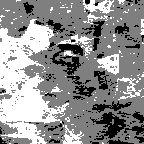
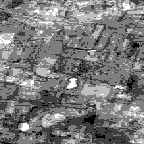
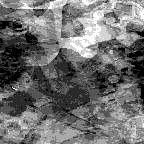
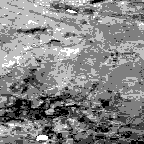
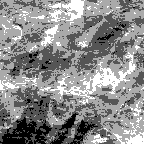
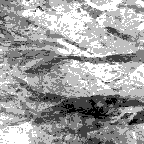
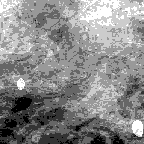
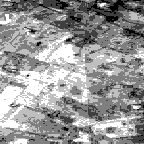
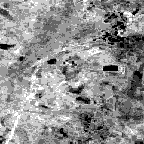
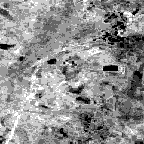
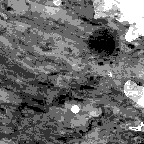
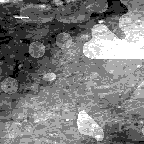
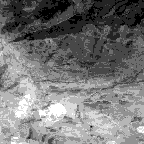
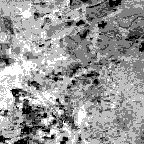
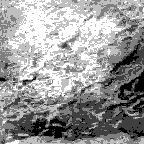
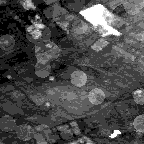
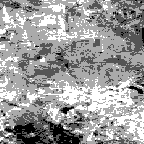
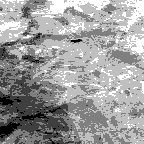
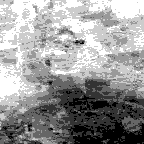
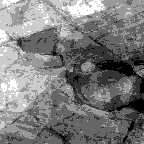
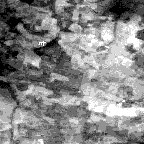
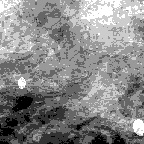
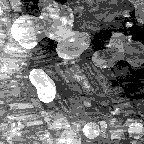
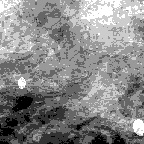
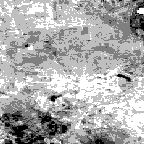
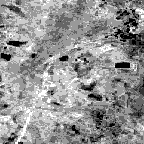
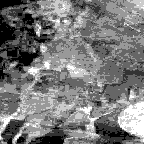
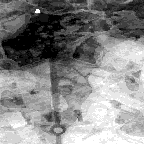
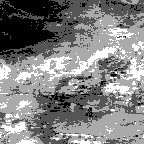
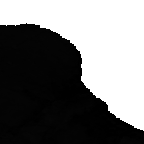
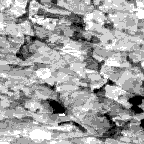
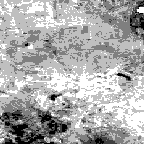
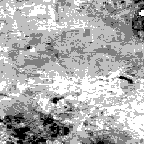
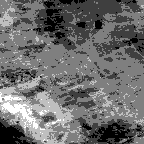
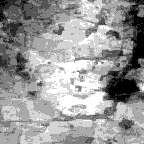
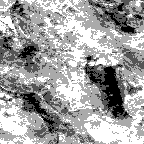
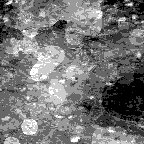
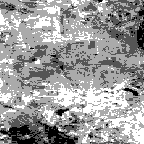
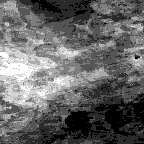
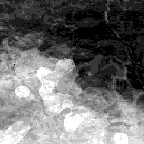
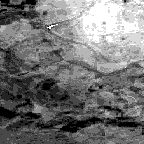
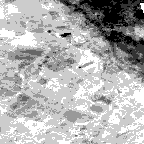
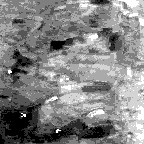
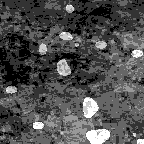
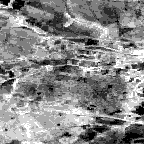
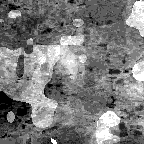
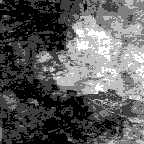
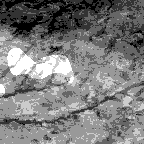
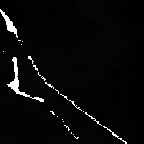
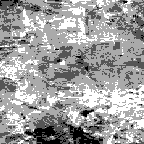
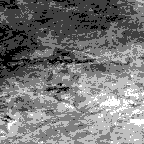
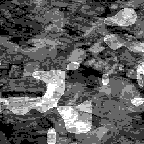

In [29]:
# @title visualization - spatial distribution of sites
import folium
from folium import Figure

import rasterio
import numpy as np
import os
base_dir = "./gee_export/sites"


fig = Figure(width=800, height=600)
m = folium.Map(location=[47, -2], zoom_start=4)


roi_geojson = feature_collection.getInfo()
folium.TileLayer(
    tiles='https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}',
    attr='Google Satellite',
    name='Satellite',
    overlay=True
).add_to(m)
folium.GeoJson(roi_geojson).add_to(m)

for site in os.listdir(base_dir):
    tif_path = os.path.join(base_dir, site, "clay_m_30m_0cm_30cm.tif")
    
    if not os.path.exists(tif_path):
        continue

    with rasterio.open(tif_path) as src:
        data = src.read(1)
        bounds = src.bounds
        
        # Normalisation des données
        data = np.nan_to_num(data)
            # Étirement linéaire (Min-Max)
            
        p_low, p_high = 2, 98  # Percentiles à utiliser
        data_min = np.percentile(data, p_low)
        data_max = np.percentile(data, p_high)
        stretched_data = (data - data_min) / (data_max - data_min)

        # Clipper les valeurs entre 0 et 1
        stretched_data = np.clip(stretched_data, 0, 1)

    folium.raster_layers.ImageOverlay(
        image=stretched_data,
        bounds=[[bounds.bottom, bounds.left], [bounds.top, bounds.right]],
        opacity=0.5,
        name=f"Site {site}"
    ).add_to(m)


fig.add_child(m)